In [ ]:
from pytorch3d.renderer import (
    PerspectiveCameras,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftSilhouetteShader,
    BlendParams,
    TexturesVertex,
 )
import open3d as o3d
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from utils import (
    build_o3d_transform_from_p3d)
import torch.nn.functional as F
from pytorch3d.transforms import (
    Rotate,
    Translate,
    Scale,
    Transform3d,
    quaternion_to_matrix,
    axis_angle_to_quaternion,
)

def compose_transform(
    scale: torch.Tensor, rotation: torch.Tensor, translation: torch.Tensor
) -> Transform3d:
    """
    Args:
        scale: (..., 3) tensor of scale factors
        rotation: (..., 3, 3) tensor of rotation matrices
        translation: (..., 3) tensor of translation vectors
    """
    tfm = Transform3d(dtype=scale.dtype, device=scale.device)
    return tfm.scale(scale).rotate(rotation).translate(translation)

def denormalize_f(norm_K, height, width):
    # Extract cx and cy from the normalized K matrix
    cx_norm = norm_K[0][2]  # c_x is at K[0][2]
    cy_norm = norm_K[1][2]  # c_y is at K[1][2]

    fx_norm = norm_K[0][0]  # Normalized fx
    fy_norm = norm_K[1][1]  # Normalized fy
    s_norm = norm_K[0][1]  # Skew (usually 0)

    # Scale to absolute values
    fx_abs = fx_norm * width
    fy_abs = fy_norm * height
    cx_abs = cx_norm * width
    cy_abs = cy_norm * height
    s_abs = s_norm * width

    # Construct absolute K matrix
    abs_K = np.array([[fx_abs, s_abs, cx_abs], [0.0, fy_abs, cy_abs], [0.0, 0.0, 1.0]])
    return abs_K
def get_mask_renderer(Mask, min_size, Intrinsics=None, device="cuda:0"):
    orig_h, orig_w = Mask.shape[-2:]
    min_orig_size = min(orig_w, orig_h)
    scale_factor = min_size / min_orig_size
    mask = F.interpolate(
        Mask[None, None],
        scale_factor=scale_factor,
        mode="bilinear",
        align_corners=False,
    )
    H, W = mask.shape[-2:]
    if Intrinsics is None:
        # normalized intrinsics (cx, cy in [0,1])
        Intrinsics = torch.tensor(
            [[1.0, 0.0, 0.5], [0.0, 1.0, 0.5], [0.0, 0.0, 1.0]],
            device=device,
            dtype=torch.float32,
        )
    intrinsics = denormalize_f(Intrinsics.cpu().numpy(), H, W)
    cameras = PerspectiveCameras(
        focal_length=torch.tensor(
            [[intrinsics[0, 0], intrinsics[1, 1]]], device=device, dtype=torch.float32
        ),
        principal_point=torch.tensor(
            [[intrinsics[0, 2], intrinsics[1, 2]]], device=device, dtype=torch.float32
        ),
        image_size=torch.tensor([[H, W]], device=device, dtype=torch.float32),
        in_ndc=False,
        device=device,
    )
    raster_settings = RasterizationSettings(
        image_size=(H, W),
        blur_radius=1e-6,
        faces_per_pixel=50,
        max_faces_per_bin=50000,
    )
    blend_params = BlendParams(sigma=1e-4, gamma=1e-4, background_color=(0.0, 0.0, 0.0))
    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
        shader=SoftSilhouetteShader(blend_params=blend_params),
    )

    return mask, renderer

In [9]:
pose_op_o3d

{'object_0': {'scale': [2.2210514545440674,
   2.2210514545440674,
   2.2210514545440674],
  'translation': [0.5450811386108398, 1.3084887266159058, 2.59499454498291],
  'rotation': [-0.004047622438520193,
   0.9900471568107605,
   -0.0008399503421969712,
   0.14067557454109192]}}

In [ ]:
pose_p3d_path = "raw_demo.json"
pose_op_o3d_path = "pose_op_o3d.json"
mesh_glb = "demo1.glb"
mask_path = "mask.png"
# load mask
mask = plt.imread(mask_path)
# load json
with open(pose_p3d_path, "r") as f:
    pose_p3d = json.load(f)
with open(pose_op_o3d_path, "r") as f:    
    pose_op_o3d = json.load(f)
mesh = o3d.io.read_triangle_mesh(mesh_glb)
transform = build_o3d_transform_from_p3d(
    quat_wxyz=np.array(pose_p3d["object_0"]["rotation"]),
    translation=np.array(pose_p3d["object_0"]["translation"]),
    scale=np.array(pose_p3d["object_0"]["scale"]),
    for_glb=True
)
mask, renderer = get_mask_renderer(torch.tensor(mask), 1024)


IoU: 0.4148


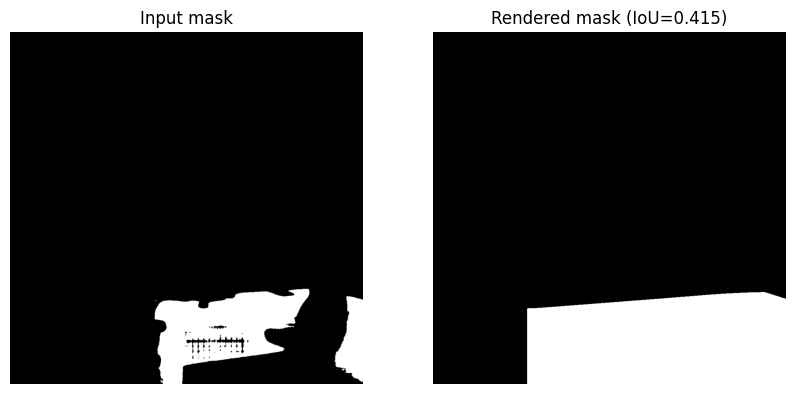

In [ ]:
# Render transformed GLB to mask and visualize
import torch, numpy as np, matplotlib.pyplot as plt
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesVertex
from utils import build_o3d_transform_from_p3d

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

verts = np.asarray(mesh.vertices)
faces = np.asarray(mesh.triangles)

# Use optimized pose (Open3D pose JSON) for best alignment
T = build_o3d_transform_from_p3d(
    quat_wxyz=np.array(pose_op_o3d["object_0"]["rotation"]),
    translation=np.array(pose_op_o3d["object_0"]["translation"]),
    scale=np.array(pose_op_o3d["object_0"]["scale"]),
    for_glb=True,
 )
verts_h = np.concatenate([verts, np.ones((verts.shape[0], 1))], axis=1)
verts = (T @ verts_h.T).T[:, :3]

verts_t = torch.tensor(verts, dtype=torch.float32, device=device)
faces_t = torch.tensor(faces, dtype=torch.int64, device=device)
textures = TexturesVertex(verts_features=torch.ones(1, verts_t.shape[0], 3, device=device))
mesh_p3d = Meshes(verts=[verts_t], faces=[faces_t], textures=textures)

rendered = renderer(mesh_p3d)
pred_mask = rendered[..., 3][0].detach().cpu().numpy()
pred_bin = pred_mask > 0.5

mask_gt = mask
if isinstance(mask_gt, torch.Tensor):
    mask_gt = mask_gt[0, 0].detach().cpu().numpy()
gt_bin = mask_gt > 0.5
inter = np.logical_and(pred_bin, gt_bin).sum()
union = np.logical_or(pred_bin, gt_bin).sum()
iou = float(inter) / float(union + 1e-8)
print("IoU:", round(iou, 4))

# Normalize for display
input_mask_vis = (mask_gt - mask_gt.min()) / (mask_gt.max() - mask_gt.min() + 1e-8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Input mask")
plt.axis("off")
plt.imshow(input_mask_vis, cmap="gray")
plt.subplot(1, 2, 2)
plt.title(f"Rendered mask (IoU={iou:.3f})")
plt.axis("off")
plt.imshow(pred_bin, cmap="gray")
plt.show()